In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian
from solve_pulses import solve_CRAB, solve_gq, solve_GRAPE
from tqdm.auto import tqdm

In [2]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

In [3]:
n_shots = 50


def measure_time(fun, *args, strict=True):
    times = []
    total_time = 0.0

    for _ in range(n_shots):
        t0 = perf_counter()
        result = fun(*args)
        tf = perf_counter() - t0
        total_time += tf

        if result is None:
            times.append(np.nan)
        else:
            times.append(tf)

        if not strict:
            if result is None:
                if tf > 2 * 60 or total_time > 5 * 60:
                    return times + [np.nan] * (n_shots - len(times))
            else:
                if tf > 3 * 60:
                    return times + [tf] * (n_shots - len(times))

    return times

In [4]:
def time_GRAPE(n_ts):
    grape_time, grape_pulse, goal_achieved = solve_GRAPE(
        H_c,
        H_d,
        psi0,
        psit,
        tf,
        n_ts,
        amp_lbound,
        amp_ubound,
        fid_err_targ,
        init_amps=np.linspace(amp_lbound, amp_ubound, n_ts),
        samples_per_slot=40,
        return_goal_achieved=True,
    )

    if goal_achieved:
        return True
    else:
        return None


def time_GRAPE_random(n_ts):
    grape_time, grape_pulse, goal_achieved = solve_GRAPE(
        H_c,
        H_d,
        psi0,
        psit,
        tf,
        n_ts,
        amp_lbound,
        amp_ubound,
        fid_err_targ,
        init_amps=np.random.rand(n_ts),
        samples_per_slot=40,
        return_goal_achieved=True,
    )

    if goal_achieved:
        return True
    else:
        return None


def time_CRAB(n_ts):
    crab_time, crab_pulse, goal_achieved = solve_CRAB(
        H_c,
        H_d,
        psi0,
        psit,
        tf,
        amp_lbound,
        amp_ubound,
        fid_err_targ,
        num_tslots=n_ts,
        return_goal_achieved=True,
    )

    if goal_achieved:
        return True
    else:
        return None


def time_gq(n_ts):
    gq_time, gq_pulse, goal_achieved = solve_gq(
        H_c,
        H_d,
        tf,
        index_0,
        alpha,
        beta,
        amp_lbound,
        amp_ubound,
        fid_err_targ,
        n_ts=n_ts,
        pulse_accuracy=n_ts,
        return_goal_achieved=True,
    )

    if goal_achieved:
        return True
    else:
        return None

# Landau-Zener

In [5]:
# ----- Define ControlModel -----
def hamiltonian_LZ(z, x):
    return np.array([[z, x], [x, -z]])


amp_lbound, amp_ubound = -10.0, 10.0
x = 1
tf = 50

alpha = 1
beta = 1

fid_err_targ = 1e-6

index_0 = 0
index_t = 0

H_initial = qt.Qobj(hamiltonian_LZ(amp_lbound, x))
H_final = qt.Qobj(hamiltonian_LZ(amp_ubound, x))

psi0 = H_initial.eigenstates()[1][index_0]
psit = H_final.eigenstates()[1][index_t]

H_c = qt.Qobj(hamiltonian_LZ(1, 0))
H_d = qt.Qobj(hamiltonian_LZ(0, x))

In [6]:
1 - (1 - fid_err_targ) ** 2

1.999999000079633e-06

In [7]:
n_points = 10
n_ts_vals = [2**i + 1 for i in range(2, 2 + n_points)]

pbar = tqdm(n_ts_vals)
times_GRAPE = np.array([measure_time(time_GRAPE, n_ts) for n_ts in pbar])

pbar = tqdm(n_ts_vals)
times_GRAPE_random = np.array([measure_time(time_GRAPE_random, n_ts) for n_ts in pbar])

pbar = tqdm(n_ts_vals)
times_gq = np.array([measure_time(time_gq, n_ts) for n_ts in pbar])

pbar = tqdm(n_ts_vals)
times_CRAB = [measure_time(time_CRAB, n_ts) for n_ts in pbar]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [8]:
np.savez(
    "data/LZ_timing_results.npz",
    n_ts_vals=n_ts_vals,
    times_GRAPE=times_GRAPE,
    times_GRAPE_random=times_GRAPE_random,
    times_gq=times_gq,
    times_CRAB=times_CRAB,
)

/tmp/ipykernel_36384/3796970041.py:2: RuntimeWarning: Mean of empty slice
  ax.loglog(n_ts_vals, np.nanmean(times_GRAPE, axis=1), ".-", label="GRAPE (linear)")


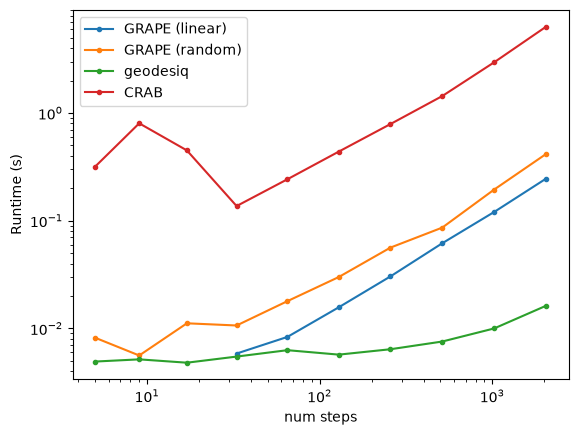

In [9]:
fig, ax = plt.subplots()
ax.loglog(n_ts_vals, np.nanmean(times_GRAPE, axis=1), ".-", label="GRAPE (linear)")
ax.loglog(n_ts_vals, np.nanmean(times_GRAPE_random, axis=1), ".-", label="GRAPE (random)")
ax.loglog(n_ts_vals, np.nanmean(times_gq, axis=1), ".-", label="geodesiq")
ax.loglog(n_ts_vals, np.nanmean(times_CRAB, axis=1), ".-", label="CRAB")

ax.set_xlabel("num steps")
ax.set_ylabel("Runtime (s)")
ax.legend();

# Many body

In [10]:
# ----- Define ControlModel -----
def ising_model(lam, L, hx, hz):
    """
    Constructs the Ising ControlModel with transverse (hx) and longitudinal (hz) fields.
    """
    zz_list = [[lam, i, i + 1] for i in range(L - 1)]
    z_list = [[lam * hz, i] for i in range(L)]
    x_list = [[(1 - lam) * hx, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list], ["x", x_list]]

    basis = spin_basis_1d(L, pblock=1)
    H = hamiltonian(static, [], basis=basis, dtype=np.float64, check_symm=False, check_herm=False)

    return H.toarray()


amp_lbound, amp_ubound = 0.1, 0.9
L, hx, hz = 4, 1, 0.8
tf = 250

alpha = 2
beta = 2

fid_err_targ = 0.00031

index_0 = 6
index_t = 6

H_initial = qt.Qobj(ising_model(amp_lbound, L, hx, hz))
H_final = qt.Qobj(ising_model(amp_ubound, L, hx, hz))

psi0 = H_initial.eigenstates()[1][index_0]
psit = H_final.eigenstates()[1][index_t]

H_d = qt.Qobj(ising_model(0, L, hx, hz))
H_c = qt.Qobj(ising_model(1, L, hx, hz)) - H_d

In [11]:
1 - (1 - fid_err_targ) ** 2

0.0006199039000001072

In [12]:
n_points = 10
n_ts_vals = [2**i + 1 for i in range(2, 2 + n_points)]

pbar = tqdm(n_ts_vals)
times_GRAPE = np.array([measure_time(time_GRAPE, n_ts) for n_ts in pbar])

pbar = tqdm(n_ts_vals)
times_GRAPE_random = np.array([measure_time(time_GRAPE_random, n_ts) for n_ts in pbar])

pbar = tqdm(n_ts_vals)
times_gq = np.array([measure_time(time_gq, n_ts) for n_ts in pbar])

pbar = tqdm(n_ts_vals)
times_CRAB = [measure_time(time_CRAB, n_ts) for n_ts in pbar]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [13]:
np.savez(
    "data/many_body_timing_results.npz",
    n_ts_vals=n_ts_vals,
    times_GRAPE=times_GRAPE,
    times_GRAPE_random=times_GRAPE_random,
    times_gq=times_gq,
    times_CRAB=times_CRAB,
)

/tmp/ipykernel_36384/3796970041.py:2: RuntimeWarning: Mean of empty slice
  ax.loglog(n_ts_vals, np.nanmean(times_GRAPE, axis=1), ".-", label="GRAPE (linear)")
/tmp/ipykernel_36384/3796970041.py:3: RuntimeWarning: Mean of empty slice
  ax.loglog(n_ts_vals, np.nanmean(times_GRAPE_random, axis=1), ".-", label="GRAPE (random)")
/tmp/ipykernel_36384/3796970041.py:4: RuntimeWarning: Mean of empty slice
  ax.loglog(n_ts_vals, np.nanmean(times_gq, axis=1), ".-", label="geodesiq")
/tmp/ipykernel_36384/3796970041.py:5: RuntimeWarning: Mean of empty slice
  ax.loglog(n_ts_vals, np.nanmean(times_CRAB, axis=1), ".-", label="CRAB")


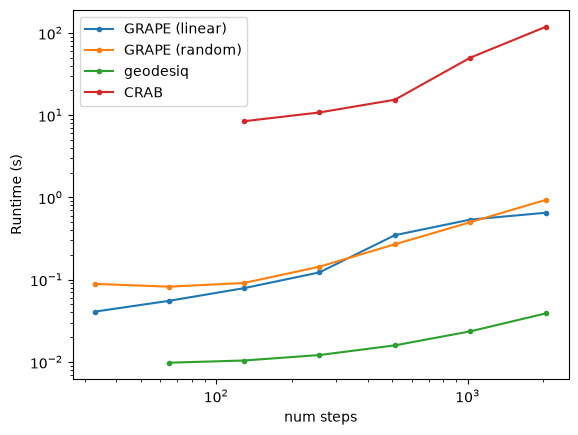

In [14]:
fig, ax = plt.subplots()
ax.loglog(n_ts_vals, np.nanmean(times_GRAPE, axis=1), ".-", label="GRAPE (linear)")
ax.loglog(n_ts_vals, np.nanmean(times_GRAPE_random, axis=1), ".-", label="GRAPE (random)")
ax.loglog(n_ts_vals, np.nanmean(times_gq, axis=1), ".-", label="geodesiq")
ax.loglog(n_ts_vals, np.nanmean(times_CRAB, axis=1), ".-", label="CRAB")

ax.set_xlabel("num steps")
ax.set_ylabel("Runtime (s)")
ax.legend();